In [14]:
setwd("/home/mjehangir/telomere-sv-analysis/data/")


In [15]:
# Load necessary libraries
#library(openxlsx)
library(dplyr)
library(tidyr)
library(ggplot2)
library(ComplexHeatmap)
library(circlize)
library(tibble)
#library(ggridges)
library(tidyverse)
  library(readr)
  library(stringr)
  library(GenomicRanges)
  library(purrr)


In [17]:
library(GenomicRanges)
library(dplyr)
library(ggplot2)
library(forcats)
library(viridis)

# --------------------------
# 1. Load repeats BED
# --------------------------
repeats <- read.delim("/home/mjehangir/softwares/SVAN/chm13/REPEATS_chm13.bed", 
                      header = TRUE, comment.char = "#")

In [18]:
HARs = read.delim("HARs_with_chr-arms.txt", 
                      header = TRUE, comment.char = "#")

In [19]:
head(HARs)

,ID,chrom,loc.start,loc.end,num.mark,seg.mean,Length,CNV_status,med_seg,mad_seg,ecDNA_flag,chr_arm
,<chr>,<int>,<int>,<int>,<int>,<dbl>,<int>,<chr>,<dbl>,<dbl>,<int>,<chr>
1,2436A,1,200151,28021140,130,0.0534,27820989,Neutral,0.0116,0.05922987,0,chr1p
2,2436A,1,142707663,142907814,2,1.3533,200151,Gain,0.0116,0.05922987,1,chr1q
3,2436A,10,88303635,101719380,68,0.0066,13415745,Neutral,0.0116,0.05922987,0,chr10q
4,2436A,10,101919615,104722905,15,-0.1040,2803290,Neutral,0.0116,0.05922987,0,chr10q
5,2436A,10,104923140,112932540,41,-0.0198,8009400,Neutral,0.0116,0.05922987,0,chr10q
6,2436A,10,113132775,120741705,39,-0.4022,7608930,Loss,0.0116,0.05922987,0,chr10q


In [30]:
HARs <- HARs %>%
  mutate(
    chrom = as.character(chrom),
    chrom = ifelse(grepl("^chr", chrom), chrom, paste0("chr", chrom))
  )


In [32]:
head(HARs)

,ID,chrom,loc.start,loc.end,num.mark,seg.mean,Length,CNV_status,med_seg,mad_seg,ecDNA_flag,chr_arm
,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<int>,<chr>,<dbl>,<dbl>,<int>,<chr>
1,2436A,chr1,200151,28021140,130,0.0534,27820989,Neutral,0.0116,0.05922987,0,chr1p
2,2436A,chr1,142707663,142907814,2,1.3533,200151,Gain,0.0116,0.05922987,1,chr1q
3,2436A,chr10,88303635,101719380,68,0.0066,13415745,Neutral,0.0116,0.05922987,0,chr10q
4,2436A,chr10,101919615,104722905,15,-0.1040,2803290,Neutral,0.0116,0.05922987,0,chr10q
5,2436A,chr10,104923140,112932540,41,-0.0198,8009400,Neutral,0.0116,0.05922987,0,chr10q
6,2436A,chr10,113132775,120741705,39,-0.4022,7608930,Loss,0.0116,0.05922987,0,chr10q


In [31]:
head(repeats)

,ref,beg,end,name,class,family,repBeg,repEnd,strand,milliDiv
,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<dbl>
1,chrM,2014,2169,REPEAT,rRNA,LSU-rRNA_Hsa,3753,3907,+,32.7
2,chrM,2653,2730,REPEAT,tRNA,tRNA-Leu-TTA(m),1,78,+,5.1
3,chrM,3752,3823,REPEAT,tRNA,tRNA-Gln-CAA_,1,72,-,16.7
4,chrM,6871,6937,REPEAT,tRNA,tRNA-Ser-TCA(m),1,68,-,13.4
5,chrM,15628,15672,REPEAT,Simple_repeat,(CAACTAT)n,1,47,+,15.4
6,chrX,2,1827,REPEAT,Simple_repeat,(CCTAAC)n,1,1827,+,1.8


In [33]:
HARs_gr <- makeGRangesFromDataFrame(
  HARs,
  seqnames.field     = "chrom",     # now looks like "chr1", "chr2", ...
  start.field        = "loc.start",
  end.field          = "loc.end",
  keep.extra.columns = TRUE
)

repeats_gr <- makeGRangesFromDataFrame(
  repeats,
  seqnames.field     = "ref",       # already "chr1", "chr2", ...
  start.field        = "beg",
  end.field          = "end",
  keep.extra.columns = TRUE
)

hits <- findOverlaps(repeats_gr, HARs_gr)


In [34]:
head(hits)

Hits object with 6 hits and 0 metadata columns:
      queryHits subjectHits
      <integer>   <integer>
  [1]    284197         213
  [2]    284197         738
  [3]    284197         892
  [4]    284197        1612
  [5]    284197        1697
  [6]    284197        1821
  -------
  queryLength: 5591079 / subjectLength: 2019

In [38]:
HARs_repeats <- tibble(
  chr    = as.character(seqnames(repeats_gr)[queryHits(hits)]),
  start  = start(repeats_gr)[queryHits(hits)],
  end    = end(repeats_gr)[queryHits(hits)],
  name   = repeats_gr$name[queryHits(hits)],
  class  = repeats_gr$class[queryHits(hits)],
  family = repeats_gr$family[queryHits(hits)],
  seg.mean   = HARs_gr$seg.mean[subjectHits(hits)],
  Length     = HARs_gr$Length[subjectHits(hits)],
  CNV_status = HARs_gr$CNV_status[subjectHits(hits)],
  med_seg    = HARs_gr$med_seg[subjectHits(hits)],
  mad_seg    = HARs_gr$mad_seg[subjectHits(hits)],
Sample_ID    = HARs_gr$ID[subjectHits(hits)],
  ecDNA_flag = HARs_gr$ecDNA_flag[subjectHits(hits)],
  chr_arm    = HARs_gr$chr_arm[subjectHits(hits)]
)


In [39]:
head(HARs_repeats)

chr,start,end,name,class,family,seg.mean,Length,CNV_status,med_seg,mad_seg,Sample_ID,ecDNA_flag,chr_arm
<chr>,<int>,<int>,<chr>,<chr>,<chr>,<dbl>,<int>,<chr>,<dbl>,<dbl>,<chr>,<int>,<chr>
chr22,15840569,15840849,REPEAT,SINE/Alu,AluY,0.0411,35085400,Neutral,-0.01770,0.11119500,3988,0,chr22q
chr22,15840569,15840849,REPEAT,SINE/Alu,AluY,-0.0516,35085400,Neutral,0.03800,0.53544099,6277A,0,chr22q
chr22,15840569,15840849,REPEAT,SINE/Alu,AluY,0.0359,35085400,Neutral,0.03770,0.04840689,6298B,0,chr22q
chr22,15840569,15840849,REPEAT,SINE/Alu,AluY,-0.0203,35085400,Neutral,0.00045,0.07776237,6436B,0,chr22q
chr22,15840569,15840849,REPEAT,SINE/Alu,AluY,0.0242,35085400,Neutral,-0.00090,0.08851122,6439C,0,chr22q
chr22,15840569,15840849,REPEAT,SINE/Alu,AluY,0.0423,35085400,Neutral,0.02255,0.05693184,6483C,0,chr22q


In [41]:
library(dplyr)
#format TE class names
HARs_repeats <- HARs_repeats %>%
  mutate(
    class = sub("/.*", "", class)  # remove "/" and everything after it
  )


In [42]:
unique(HARs_repeats$class)

[1] "SINE"           "Simple_repeat"  "Low_complexity" "DNA"           
 [5] "LINE"           "LTR"            "snRNA"          "Satellite"     
 [9] "scRNA"          "Unknown"        "LTR?"           "RC"            
[13] "Retroposon"     "srpRNA"         "rRNA"           "RC?"           
[17] "DNA?"           "tRNA"           "Unspecified"

In [54]:
library(dplyr)
library(ggplot2)
library(forcats)

# 1) Define main classes and colors (now including Retroposon)
main_classes <- c("SINE", "LTR", "LINE", "Retroposon", "DNA", "Satellite")

class_colors <- c(
  SINE       = "red4",
  LTR        = "red3",
  LINE       = "red2",
  Retroposon = "orangered",
  DNA        = "darkgreen",
  Satellite  = "grey",
  Others     = "grey70"
)

# 2) Recode class into main groups + Others
HARs_repeats2 <- HARs_repeats %>%
  mutate(
    class_group = ifelse(class %in% main_classes, class, "Others"),
    class_group = factor(
      class_group,
      levels = c("SINE", "LTR", "LINE", "Retroposon", "DNA", "Satellite", "Others")
    )
  )

# 3) Summarise counts and percentages per Sample_ID × class_group
class_summary <- HARs_repeats2 %>%
  count(Sample_ID, class_group, name = "n") %>%
  group_by(Sample_ID) %>%
  mutate(pct = 100 * n / sum(n)) %>%
  ungroup()

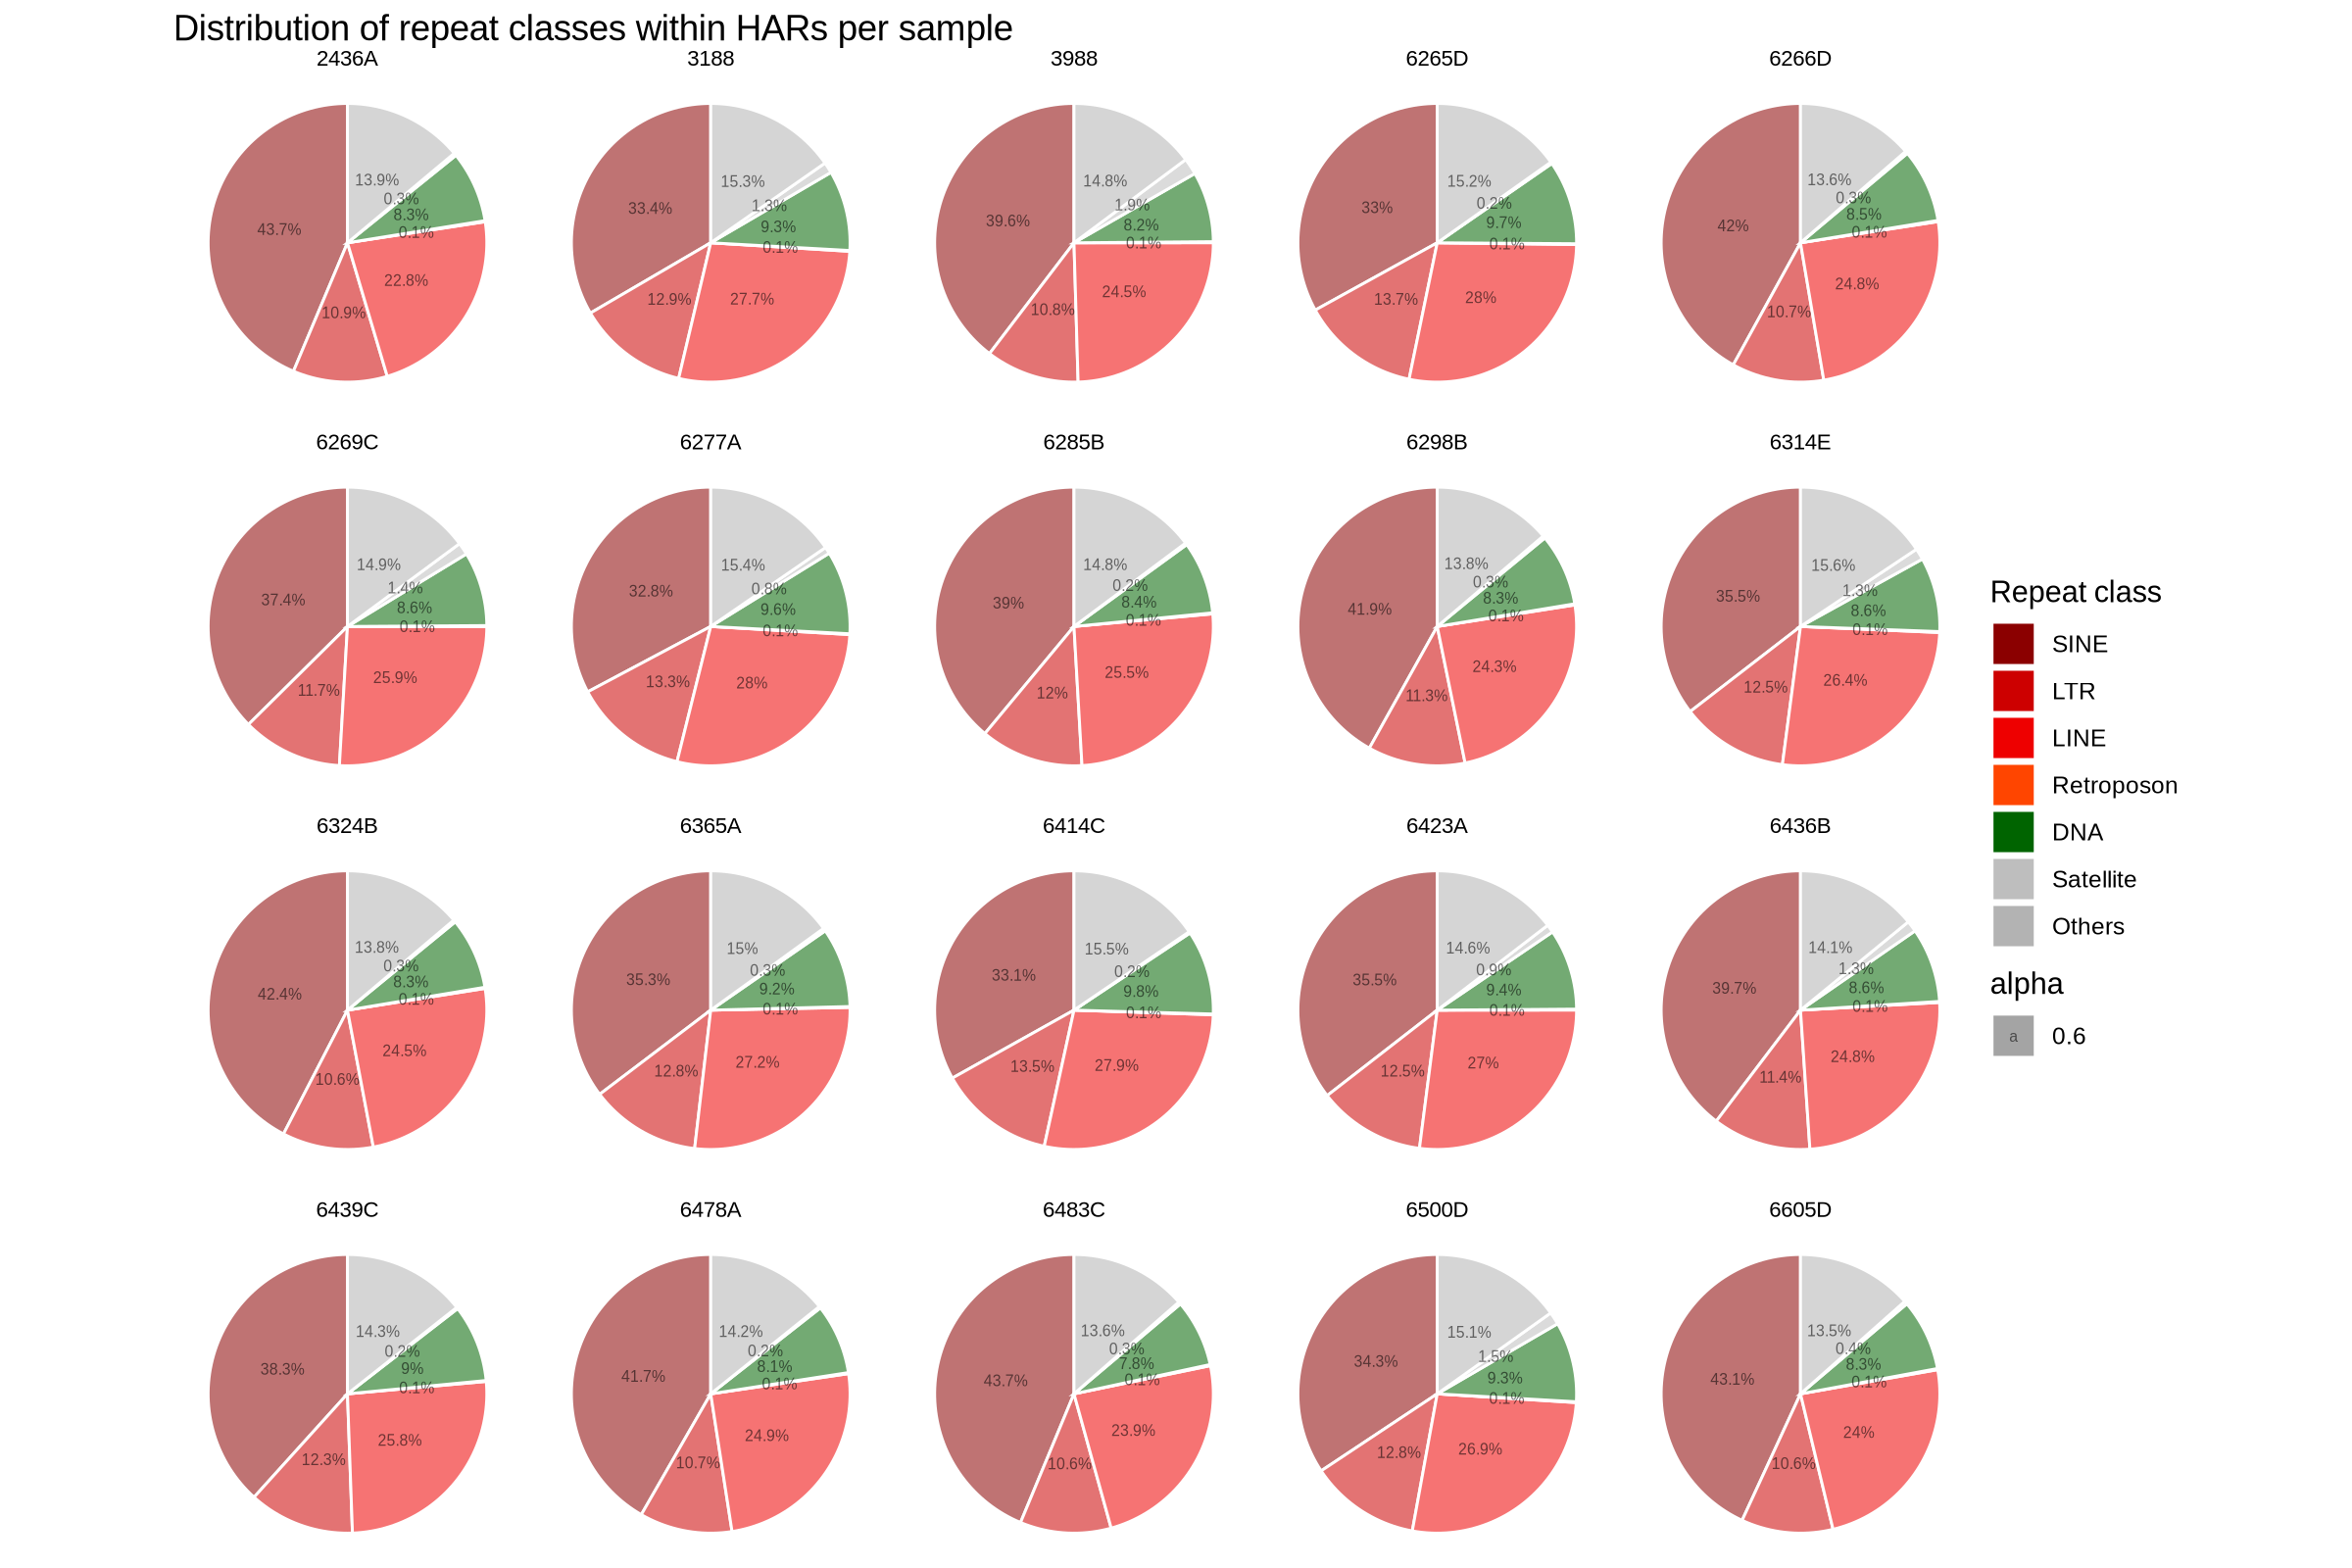

In [55]:

options(repr.plot.width = 12, repr.plot.height = 8, repr.plot.res = 200)
# 4) Facetted pie charts: one per Sample_ID, 5 per row
ggplot(class_summary, aes(x = "", y = pct, fill = class_group, alpha = 0.6)) +
  geom_col(width = 1, color = "white") +
  coord_polar(theta = "y") +
  facet_wrap(~ Sample_ID, ncol = 5) +
  geom_text(
    aes(label = paste0(round(pct, 1), "%")),
    position = position_stack(vjust = 0.5),
    size = 2
  ) +
  scale_fill_manual(values = class_colors, name = "Repeat class") +
  theme_void() +
  theme(
    strip.text = element_text(size = 8),
    legend.position = "right"
  ) +
  labs(
    title = "Distribution of repeat classes within HARs per sample"
  )

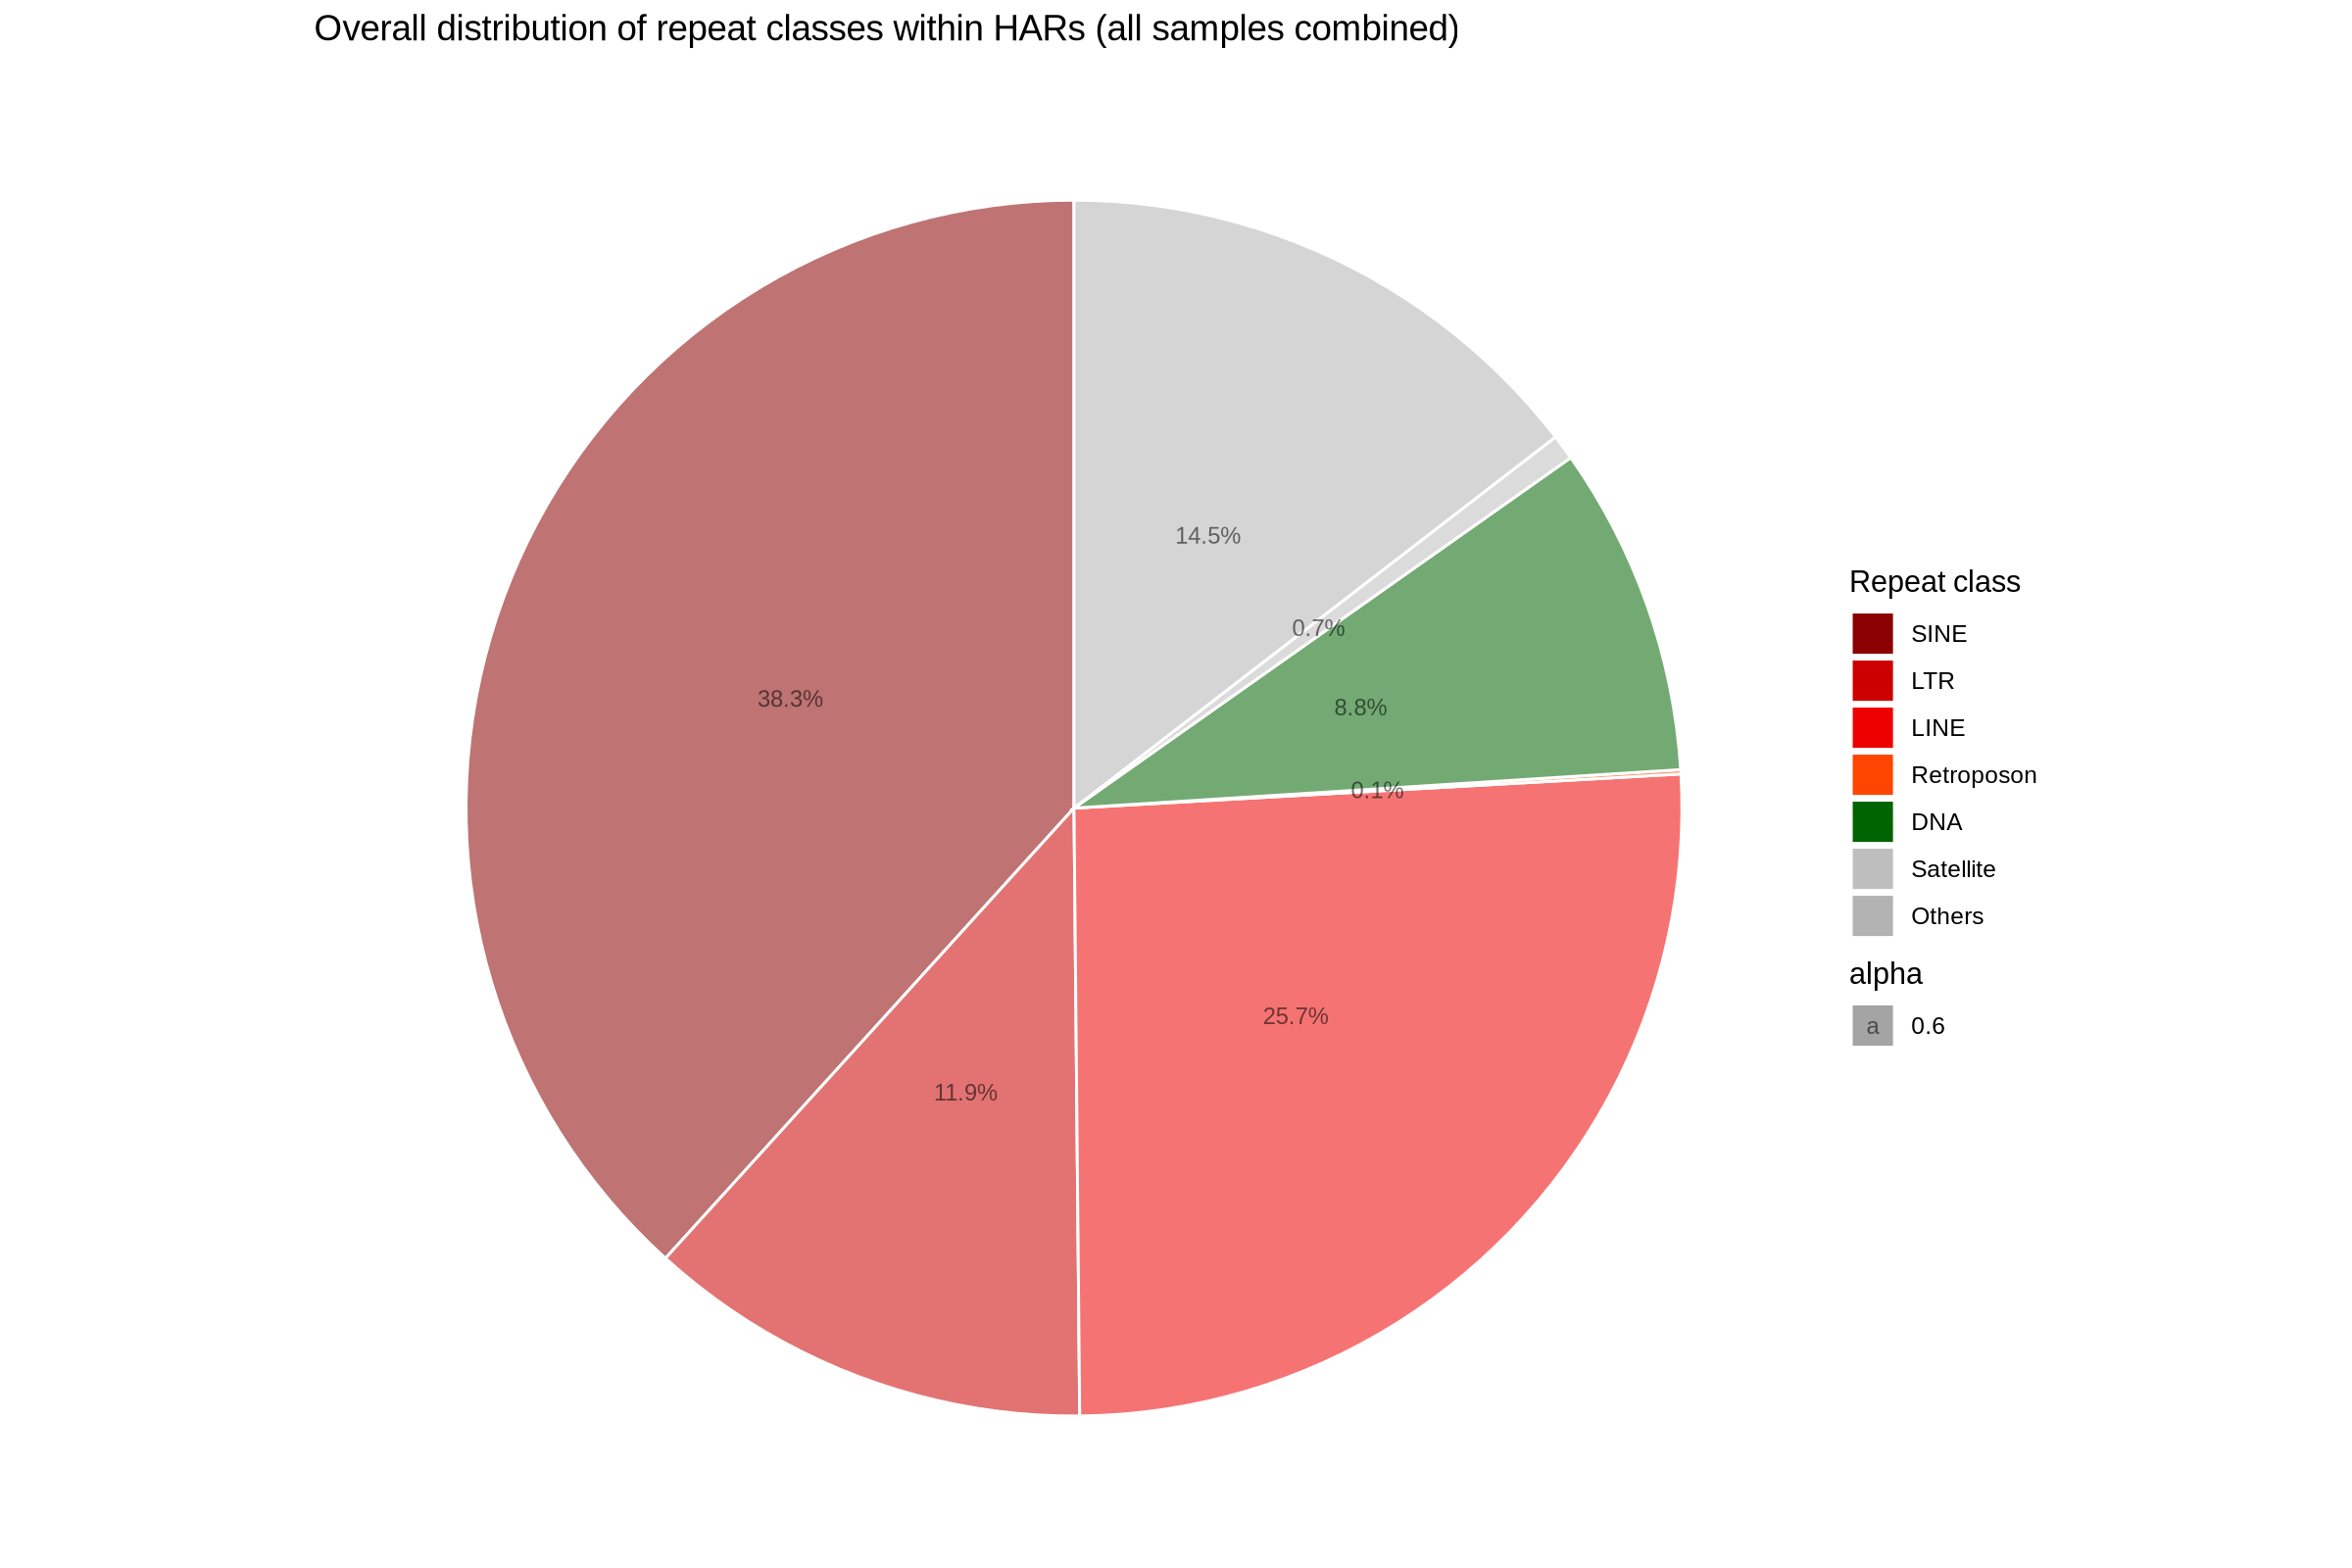

In [56]:
library(dplyr)
library(ggplot2)

# ---- Combine percentages across all samples ----
overall_summary <- class_summary %>%
  group_by(class_group) %>%
  summarise(total = sum(pct)) %>%
  ungroup() %>%
  mutate(pct = total / sum(total) * 100)

# ---- Single pie chart ----
ggplot(overall_summary, aes(x = "", y = pct, fill = class_group, alpha = 0.6)) +
  geom_col(width = 1, color = "white") +
  coord_polar(theta = "y") +
  geom_text(
    aes(label = paste0(round(pct, 1), "%")),
    position = position_stack(vjust = 0.5),
    size = 3
  ) +
  scale_fill_manual(values = class_colors, name = "Repeat class") +
  theme_void() +
  labs(
    title = "Overall distribution of repeat classes within HARs (all samples combined)"
  )
